# Tutorial 3: Cloud Detector Step-by-Step

Walkthrough of the internal mechanisms of the cloud detector.

In [38]:
import torch
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from panoseti_analysis.io.models import load_classifier

## Load Model

In [39]:
model, bundle = load_classifier(Path("../../assets/models/cloud_detector_v1.pt"))
model.eval()
print("Model architecture:", model)

Model architecture: CloudDetection(
  (conv1): Sequential(
    (0): Conv2d(2, 28, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=2)
    (1): ReLU()
    (2): BatchNorm2d(28, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout2d(p=0.5, inplace=False)
    (4): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=2)
    (5): ReLU()
    (6): BatchNorm2d(28, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Dropout2d(p=0.5, inplace=False)
    (8): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=2)
    (9): ReLU()
    (10): BatchNorm2d(28, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): Dropout2d(p=0.5, inplace=False)
    (12): Conv2d(28, 28, kernel_size=(3, 3), stride=(1, 1), padding=same, groups=2)
    (13): ReLU()
    (14): BatchNorm2d(28, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (15): MaxPool2

## Feature Extraction (Hann Window + FFT)

<xarray.Dataset> Size: 8kB
Dimensions:            (T_l2: 1, H: 32, W: 32)
Dimensions without coordinates: T_l2, H, W
Data variables:
    feature_deriv_fft  (T_l2, H, W) float32 4kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
    cloud_score        (T_l2) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    feature_raw_fft    (T_l2, H, W) float32 4kB dask.array<chunksize=(1, 32, 32), meta=np.ndarray>
    cloud_label        (T_l2) uint8 1B dask.array<chunksize=(1,), meta=np.ndarray>
    unix_t_ns          (T_l2) int64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/15)
    panoseti_pff_zarr_version:          1.0
    data_product:                       img16
    bytes_per_pixel:                    2
    module:                             1
    source_pff_files:                   ['start_2024-07-25T04_34_46Z.dp_img16...
    total_frames:                       4128
    ...                                 ...
    frame_config:                       {'header_size': 491, 'payload_size': ...
    processing_history:                 [{'step_name': 'convert', 'step_versi...
    data_level:                         L2
    panoseti_analysis_storage_version:  2.0
    calibration:                        {'kind': 'img', 'frame_stride': 50, '...
    timestamp_qc:                       {'status': 'clean', 'monotonic': True...

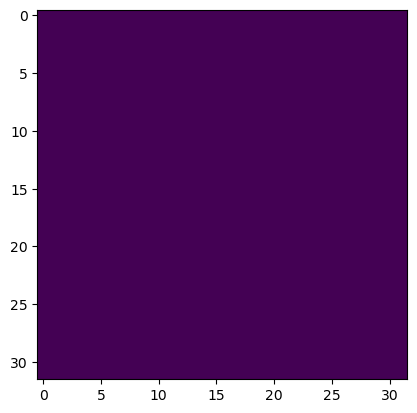

In [40]:
ds_l2 = xr.open_zarr("results_tutorial/L2/obs_TEST.cloud.module_1.zarr", consolidated=False)
display(ds_l2)
plt.imshow(np.log(ds_l2['feature_deriv_fft'][0] + 1e-7))

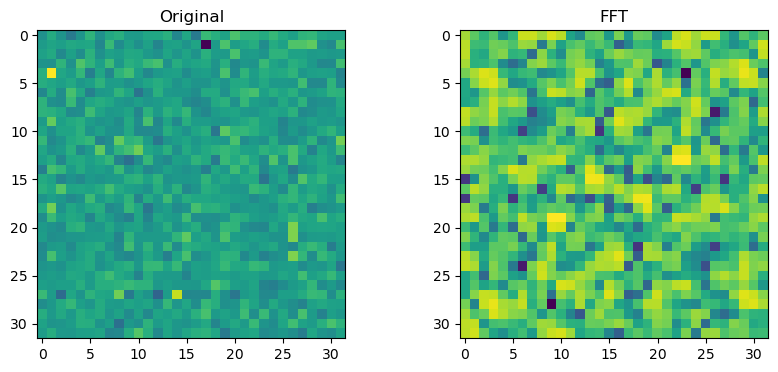

In [42]:
ds_l1 = xr.open_zarr("results_tutorial/L1/obs_TEST.dp_img16.module_1.L1.zarr", consolidated=False)
img = ds_l1["median_subtracted"].values

# Get a single frame
frame = img[0]
hann_2d = np.outer(np.hanning(32), np.hanning(32))

fft = np.abs(np.fft.fftn(frame * hann_2d))
fft = np.log(np.fft.fftshift(fft))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(frame)
ax1.set_title("Original")
ax2.imshow(fft)
ax2.set_title("FFT")
plt.show()